# Demo 3: API Usage and Prompt Engineering for Health Data

This demo explores how to effectively use language model APIs for healthcare applications, focusing on prompt engineering techniques to improve reliability and reduce hallucination.

## Setup

First, let's install the necessary packages:

In [1]:
# Install required packages
%pip install -q openai python-dotenv pandas numpy matplotlib seaborn

%reset -f

# Import packages
import os
import json
from typing import List, Dict, Any
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Getting Your API Key

To use the OpenAI API, you'll need an API key:

1. Go to [platform.openai.com](https://platform.openai.com)
2. Sign up or log in to your account
3. Navigate to "API Keys" in the left sidebar
4. Click "Create new secret key"
5. Copy your API key and store it securely

For this demo, you can create a `.env` file in your working directory with: `OPENAI_API_KEY=your_api_key_here`

In [2]:
# Configure OpenAI API client
load_dotenv()  # Load API key from .env file
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

# Set model to use
MODEL_NAME = "gpt-4o-mini"  # Using a smaller, more cost-effective model

## Zero-Shot Learning

Let's start with zero-shot learning for medical text classification:

In [3]:
def classify_medical_text(text: str, categories: List[str]) -> Dict[str, Any]:
    """
    Classify medical text into predefined categories using zero-shot learning.
    """
    prompt = f"""Classify the following medical text into one of these categories: {', '.join(categories)}.
    
Text: {text}

Provide the classification in JSON format with the following structure:
{{
    "category": "chosen_category",
    "confidence": confidence_score,
    "explanation": "brief explanation"
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical text classification expert."},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {e}")
        return {"error": str(e)}

# Example usage
categories = ["Diagnosis", "Treatment", "Prognosis", "Medical History"]
text = "Patient presents with persistent cough and fever for 3 days. Chest X-ray shows right lower lobe infiltrate. Started on azithromycin 500mg daily."

result = classify_medical_text(text, categories)
print(json.dumps(result, indent=2))

{
  "category": "Treatment",
  "confidence": 0.95,
  "explanation": "The text describes the initiation of a specific treatment (azithromycin) for the patient's condition, which is indicated by the symptoms and chest X-ray findings."
}


## One-Shot Learning

Now let's try one-shot learning for medical report generation:

In [4]:
def generate_medical_report(patient_data: Dict[str, Any]) -> str:
    """
    Generate a medical report using one-shot learning.
    """
    example = {
        "patient_id": "P12345",
        "age": 45,
        "symptoms": ["fever", "cough", "fatigue"],
        "vitals": {"temperature": 38.5, "heart_rate": 95, "blood_pressure": "120/80"},
        "diagnosis": "Acute bronchitis"
    }
    
    example_report = """MEDICAL REPORT
Patient ID: P12345
Age: 45

SYMPTOMS:
- Fever
- Cough
- Fatigue

VITAL SIGNS:
- Temperature: 38.5°C
- Heart Rate: 95 bpm
- Blood Pressure: 120/80 mmHg

DIAGNOSIS:
Acute bronchitis

RECOMMENDATIONS:
1. Rest and adequate hydration
2. Over-the-counter antipyretics for fever
3. Follow-up in 1 week if symptoms persist"""

    prompt = f"""Generate a medical report following this exact format:

{example_report}

Now generate a report for this patient data:
{json.dumps(patient_data, indent=2)}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical report generation expert."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API Error: {str(e)}")
        return f"Error generating report: {str(e)}"

# Example usage
patient_data = {
    "patient_id": "P67890",
    "age": 62,
    "symptoms": ["chest pain", "shortness of breath", "sweating"],
    "vitals": {"temperature": 37.2, "heart_rate": 110, "blood_pressure": "145/90"},
    "diagnosis": "Suspected angina"
}

report = generate_medical_report(patient_data)
print(report)

MEDICAL REPORT  
Patient ID: P67890  
Age: 62  

SYMPTOMS:  
- Chest pain  
- Shortness of breath  
- Sweating  

VITAL SIGNS:  
- Temperature: 37.2°C  
- Heart Rate: 110 bpm  
- Blood Pressure: 145/90 mmHg  

DIAGNOSIS:  
Suspected angina  

RECOMMENDATIONS:  
1. Immediate evaluation by a cardiologist  
2. Avoid strenuous activities until further assessment  
3. Consider nitroglycerin for chest pain if prescribed  
4. Follow-up appointment within 48 hours or sooner if symptoms worsen  


## Few-Shot Learning

Let's implement few-shot learning for medical coding:

In [5]:
def assign_icd_codes(clinical_note: str, num_examples: int = 3) -> List[Dict[str, Any]]:
    """
    Assign ICD-10 codes to a clinical note using few-shot learning.
    """
    examples = [
        {
            "note": "Patient presents with type 2 diabetes mellitus, uncontrolled. HbA1c 9.2%. Also reports diabetic retinopathy.",
            "codes": [
                {"code": "E11.9", "description": "Type 2 diabetes mellitus without complications"},
                {"code": "E11.3", "description": "Type 2 diabetes mellitus with ophthalmic complications"}
            ]
        },
        {
            "note": "Acute appendicitis with localized peritonitis. Patient taken to OR for appendectomy.",
            "codes": [
                {"code": "K35.2", "description": "Acute appendicitis with localized peritonitis"},
                {"code": "47.01", "description": "Laparoscopic appendectomy"}
            ]
        },
        {
            "note": "Hypertensive heart disease with heart failure. Patient on ACE inhibitor and diuretic.",
            "codes": [
                {"code": "I11.0", "description": "Hypertensive heart disease with heart failure"},
                {"code": "I50.9", "description": "Heart failure, unspecified"}
            ]
        }
    ]
    
    # Select examples
    selected_examples = examples[:num_examples]
    
    prompt = f"""Assign ICD-10 codes to the following clinical notes. Here are some examples:

{json.dumps(selected_examples, indent=2)}

Now assign codes to this note:
{clinical_note}

Provide the codes in JSON format with the following structure:
[
    {{
        "code": "ICD-10 code",
        "description": "code description"
    }}
]"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical coding expert."},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        # The response will be a JSON object with a single property containing the array
        result = json.loads(response.choices[0].message.content)
        
        # If the result is a dictionary with a single key containing an array, extract the array
        if isinstance(result, dict) and len(result) == 1 and isinstance(list(result.values())[0], list):
            return list(result.values())[0]
        
        # If the result is already an array, return it
        if isinstance(result, list):
            return result
            
        # Otherwise, wrap the result in an array
        return [{"codes": result}]
    except Exception as e:
        print(f"API Error: {str(e)}")
        return [{"error": str(e)}]

# Example usage
note = "Patient with chronic obstructive pulmonary disease, severe. Presents with acute exacerbation. Started on prednisone and antibiotics."
codes = assign_icd_codes(note)
print(json.dumps(codes, indent=2))

[
  {
    "code": "J44.1",
    "description": "Chronic obstructive pulmonary disease with acute exacerbation"
  },
  {
    "code": "J44.9",
    "description": "Chronic obstructive pulmonary disease, unspecified"
  }
]


## Comparing Effectiveness of Shot Learning Approaches

Let's directly compare zero-shot, one-shot, and few-shot learning on the same medical diagnosis task:

Zero-Shot Learning:


{
  "diagnosis": "Community-acquired pneumonia",
  "confidence": 0.85,
  "reasoning": "The patient presents with a persistent cough and fever, which are common symptoms of pneumonia. The chest X-ray findings of right lower lobe infiltrate further support this diagnosis, indicating a possible infection in that area of the lung. Azithromycin is an appropriate choice for treating community-acquired pneumonia, particularly if a bacterial cause is suspected."
}

One-Shot Learning:


{
  "diagnosis": "Community-acquired pneumonia",
  "confidence": 0.85,
  "reasoning": "The presence of persistent cough, fever, and chest X-ray findings of right lower lobe infiltrate are indicative of pneumonia. The initiation of azithromycin suggests a clinical suspicion of bacterial infection, commonly seen in community-acquired pneumonia."
}

Few-Shot Learning:


{
  "case": "Patient presents with persistent cough and fever for 3 days. Chest X-ray shows right lower lobe infiltrate. Started on azithromycin 500mg daily.",
  "diagnosis": {
    "diagnosis": "Community-acquired pneumonia",
    "confidence": 0.85,
    "reasoning": "The presence of fever, persistent cough, and radiographic evidence of infiltrate in the right lower lobe suggests a diagnosis of pneumonia. The initiation of azithromycin indicates a suspicion of a bacterial cause, which aligns with community-acquired pneumonia."
  }
}


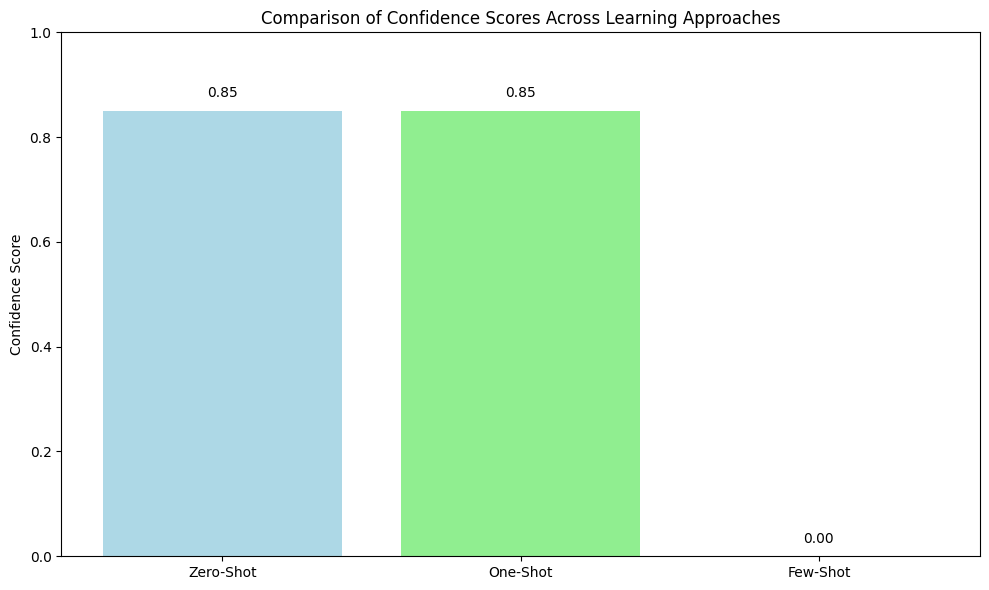


Comparison Table:
    Approach                                          Diagnosis  Confidence  \
0  Zero-Shot                       Community-acquired pneumonia        0.85   
1   One-Shot                       Community-acquired pneumonia        0.85   
2   Few-Shot  {'diagnosis': 'Community-acquired pneumonia', ...        0.00   

  Detail Level  Reasoning Length  
0          Low               370  
1       Medium               257  
2         High                 0  


In [6]:
def diagnose_with_shot_learning(clinical_case: str, approach: str) -> Dict[str, Any]:
    """
    Diagnose a clinical case using different shot learning approaches.
    
    Parameters:
    - clinical_case: The clinical case to diagnose
    - approach: One of "zero-shot", "one-shot", or "few-shot"
    """
    if approach == "zero-shot":
        # Zero-shot approach: No examples provided
        prompt = f"""Diagnose the following clinical case:

Clinical case: {clinical_case}

Provide your diagnosis in JSON format with the following structure:
{{
    "diagnosis": "your diagnosis",
    "confidence": confidence_score (between 0 and 1),
    "reasoning": "brief explanation of your reasoning"
}}"""

        system_role = "You are a medical diagnostician."
        
    elif approach == "one-shot":
        # One-shot approach: One example provided
        example_case = """Patient presents with fever (39°C), productive cough with yellow sputum for 5 days, and shortness of breath. Physical exam reveals crackles in the left lower lobe. WBC is 14,000. Chest X-ray shows left lower lobe consolidation."""
        
        example_diagnosis = {
            "diagnosis": "Community-acquired pneumonia",
            "confidence": 0.9,
            "reasoning": "The combination of fever, productive cough, elevated WBC, and radiographic evidence of consolidation is highly suggestive of bacterial pneumonia."
        }
        
        prompt = f"""Diagnose the following clinical case based on the example:

Example case: {example_case}

Example diagnosis:
{json.dumps(example_diagnosis, indent=2)}

Now diagnose this case:
{clinical_case}

Provide your diagnosis in the same JSON format as the example."""

        system_role = "You are a medical diagnostician."
        
    elif approach == "few-shot":
        # Few-shot approach: Multiple examples provided
        examples = [
            {
                "case": "Patient presents with fever (39°C), productive cough with yellow sputum for 5 days, and shortness of breath. Physical exam reveals crackles in the left lower lobe. WBC is 14,000. Chest X-ray shows left lower lobe consolidation.",
                "diagnosis": {
                    "diagnosis": "Community-acquired pneumonia",
                    "confidence": 0.9,
                    "reasoning": "The combination of fever, productive cough, elevated WBC, and radiographic evidence of consolidation is highly suggestive of bacterial pneumonia."
                }
            },
            {
                "case": "Patient presents with sudden onset chest pain that radiates to the left arm, associated with nausea and diaphoresis. ECG shows ST elevation in leads II, III, and aVF. Troponin is elevated.",
                "diagnosis": {
                    "diagnosis": "Acute inferior myocardial infarction",
                    "confidence": 0.95,
                    "reasoning": "The clinical presentation, ECG findings, and elevated troponin are diagnostic of an acute MI involving the inferior wall of the heart."
                }
            },
            {
                "case": "Patient presents with right upper quadrant pain, fever, and jaundice. Labs show elevated WBC, total bilirubin, and alkaline phosphatase. Ultrasound shows gallstones and dilated common bile duct.",
                "diagnosis": {
                    "diagnosis": "Acute cholangitis",
                    "confidence": 0.85,
                    "reasoning": "The triad of RUQ pain, fever, and jaundice (Charcot's triad) along with imaging findings of biliary obstruction are consistent with acute cholangitis."
                }
            }
        ]
        
        prompt = f"""Diagnose the following clinical case based on these examples:

Examples:
{json.dumps(examples, indent=2)}

Now diagnose this case:
{clinical_case}

Provide your diagnosis in the same JSON format as the examples."""

        system_role = "You are a medical diagnostician with expertise in pattern recognition."
    
    else:
        raise ValueError(f"Unknown approach: {approach}. Must be one of 'zero-shot', 'one-shot', or 'few-shot'.")
    
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_role},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e), "diagnosis": "Error", "confidence": 0, "reasoning": ""}

# Example clinical case
clinical_case = "Patient presents with persistent cough and fever for 3 days. Chest X-ray shows right lower lobe infiltrate. Started on azithromycin 500mg daily."

# Compare the three approaches
print("Zero-Shot Learning:")
zero_shot_result = diagnose_with_shot_learning(clinical_case, "zero-shot")
print(json.dumps(zero_shot_result, indent=2))
print("\nOne-Shot Learning:")
one_shot_result = diagnose_with_shot_learning(clinical_case, "one-shot")
print(json.dumps(one_shot_result, indent=2))
print("\nFew-Shot Learning:")
few_shot_result = diagnose_with_shot_learning(clinical_case, "few-shot")
print(json.dumps(few_shot_result, indent=2))

# Ensure we have valid confidence scores for visualization
def get_confidence(result):
    if isinstance(result, dict) and "confidence" in result and isinstance(result["confidence"], (int, float)):
        return result["confidence"]
    return 0

# Visualize confidence scores
approaches = ["Zero-Shot", "One-Shot", "Few-Shot"]
confidence_scores = [
    get_confidence(zero_shot_result),
    get_confidence(one_shot_result),
    get_confidence(few_shot_result)
]

plt.figure(figsize=(10, 6))
bars = plt.bar(approaches, confidence_scores, color=['lightblue', 'lightgreen', 'coral'])
plt.ylim(0, 1.0)
plt.ylabel('Confidence Score')
plt.title('Comparison of Confidence Scores Across Learning Approaches')

# Add the values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create a comparison table
def get_diagnosis(result):
    if isinstance(result, dict) and "diagnosis" in result:
        return result["diagnosis"]
    return "N/A"

def get_reasoning_length(result):
    if isinstance(result, dict) and "reasoning" in result and isinstance(result["reasoning"], str):
        return len(result["reasoning"])
    return 0

comparison_data = {
    'Approach': approaches,
    'Diagnosis': [
        get_diagnosis(zero_shot_result),
        get_diagnosis(one_shot_result),
        get_diagnosis(few_shot_result)
    ],
    'Confidence': confidence_scores,
    'Detail Level': ['Low', 'Medium', 'High'],
    'Reasoning Length': [
        get_reasoning_length(zero_shot_result),
        get_reasoning_length(one_shot_result),
        get_reasoning_length(few_shot_result)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparison Table:")
print(comparison_df)

## Schema-Based Prompting

Schema-based prompting is a powerful technique for extracting structured information from unstructured medical text:

In [7]:
def extract_structured_data(text: str, schema: Dict[str, Any]) -> Dict[str, Any]:
    """
    Extract structured data from medical text using schema-based prompting.
    """
    prompt = f"""Extract information from the following medical text according to this schema:
{json.dumps(schema, indent=2)}

Text: {text}

Provide the extracted data in JSON format matching the schema exactly.
If a field is not found in the text, use null as the value."""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical information extraction expert."},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}

# Example usage
schema = {
    "patient_demographics": {
        "age": "number",
        "gender": "string",
        "race": "string"
    },
    "vital_signs": {
        "temperature": "number",
        "heart_rate": "number",
        "blood_pressure": "string",
        "oxygen_saturation": "number"
    },
    "medications": {
        "current_meds": ["string"],
        "allergies": ["string"]
    }
}

text = """45-year-old African American male presents to ED. 
Vitals: T 38.2, HR 110, BP 145/90, O2 sat 96% on room air.
Current medications: Lisinopril 10mg daily, Metformin 1000mg BID.
Allergies: Penicillin, Sulfa drugs."""

structured_data = extract_structured_data(text, schema)
print(json.dumps(structured_data, indent=2))

{
  "patient_demographics": {
    "age": 45,
    "gender": "male",
    "race": "African American"
  },
  "vital_signs": {
    "temperature": 38.2,
    "heart_rate": 110,
    "blood_pressure": "145/90",
    "oxygen_saturation": 96
  },
  "medications": {
    "current_meds": [
      "Lisinopril 10mg daily",
      "Metformin 1000mg BID"
    ],
    "allergies": [
      "Penicillin",
      "Sulfa drugs"
    ]
  }
}


## Chain-of-Thought Prompting

Chain-of-thought prompting guides the model through a step-by-step reasoning process:

In [8]:
def analyze_medical_case(case: str) -> Dict[str, Any]:
    """
    Analyze a medical case using chain-of-thought prompting.
    """
    prompt = f"""Analyze this medical case step by step:

{case}

Follow these steps:
1. List the key symptoms and findings
2. Identify potential differential diagnoses
3. Explain your reasoning for each diagnosis
4. Recommend next steps for diagnosis
5. Suggest initial treatment approach

Provide your analysis in JSON format with the following structure:
{{
    "symptoms": ["list of symptoms"],
    "findings": ["list of findings"],
    "differential_diagnoses": [
        {{
            "diagnosis": "diagnosis name",
            "probability": "high/medium/low",
            "reasoning": "explanation"
        }}
    ],
    "next_steps": ["list of recommended steps"],
    "treatment": ["list of treatment suggestions"]
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical case analysis expert."},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}

# Example usage
case = """A 35-year-old woman presents with 3 days of right upper quadrant pain, 
fever to 38.5°C, and nausea. Physical exam shows right upper quadrant tenderness 
and positive Murphy's sign. WBC is 15,000 with 85% neutrophils. 
Ultrasound shows gallbladder wall thickening and pericholecystic fluid."""

analysis = analyze_medical_case(case)
print(json.dumps(analysis, indent=2))

{
  "symptoms": [
    "right upper quadrant pain",
    "fever to 38.5\u00b0C",
    "nausea"
  ],
  "findings": [
    "right upper quadrant tenderness",
    "positive Murphy's sign",
    "WBC count of 15,000 with 85% neutrophils",
    "gallbladder wall thickening",
    "pericholecystic fluid on ultrasound"
  ],
  "differential_diagnoses": [
    {
      "diagnosis": "Acute Cholecystitis",
      "probability": "high",
      "reasoning": "The presence of right upper quadrant pain, fever, elevated WBC count with neutrophilia, positive Murphy's sign, gallbladder wall thickening, and pericholecystic fluid strongly suggests acute cholecystitis."
    },
    {
      "diagnosis": "Cholelithiasis (Gallstones)",
      "probability": "medium",
      "reasoning": "While gallstones can cause similar symptoms, the presence of pericholecystic fluid and gallbladder wall thickening indicates a complication, likely acute cholecystitis rather than simple gallstones."
    },
    {
      "diagnosis": "Pancrea

## Error Handling and Validation

Let's add some basic error handling to make our code more robust:

In [9]:
def extract_medical_entities(text: str) -> Dict[str, Any]:
    """
    Extract medical entities from text with error handling.
    """
    prompt = f"""Extract all medical entities from the following text:
    
Text: {text}

Categorize them into:
- Conditions
- Medications
- Procedures
- Lab tests
- Vital signs

Return the results in JSON format with the following structure:
{{
    "conditions": ["list of conditions"],
    "medications": ["list of medications"],
    "procedures": ["list of procedures"],
    "lab_tests": ["list of lab tests"],
    "vital_signs": ["list of vital signs"]
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical NLP expert."},
                {"role": "user", "content": prompt}
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3
        )
        
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}

# Example usage
sample_text = "Patient with history of hypertension and type 2 diabetes. Recent CBC shows elevated WBC. Taking lisinopril and metformin."
entities = extract_medical_entities(sample_text)
print(json.dumps(entities, indent=2))

{
  "conditions": [
    "hypertension",
    "type 2 diabetes"
  ],
  "medications": [
    "lisinopril",
    "metformin"
  ],
  "procedures": [],
  "lab_tests": [
    "CBC"
  ],
  "vital_signs": []
}


## Key Takeaways

1. **Prompt Engineering Techniques**
   - **Zero-shot learning** requires no examples but may produce less specific results. It's ideal for simple, common tasks where examples aren't available.
   - **One-shot learning** provides a single example that significantly improves output quality with minimal overhead. This approach is very efficient for formatting tasks.
   - **Few-shot learning** uses multiple examples to help the model recognize patterns, producing more detailed and confident results. Best for complex tasks where accuracy is critical.
   - **Chain-of-thought prompting** guides the model through step-by-step reasoning, mimicking clinical decision-making processes and ensuring thorough analysis.
   - **Schema-based prompting** extracts structured information from unstructured text, essential for converting clinical notes into analyzable data.

2. **Structured Output**
   - JSON schema for consistent formatting ensures interoperability with other systems
   - Clear instructions for data extraction improve reliability and completeness
   - Validation of extracted information prevents propagation of errors
   - Structured outputs facilitate downstream processing and analysis

3. **Healthcare-Specific Considerations**
   - Medical terminology accuracy is critical for clinical applications
   - Clinical reasoning transparency helps build trust with healthcare professionals
   - Ethical and privacy concerns must be addressed when handling patient data
   - Reliability and robustness are essential when systems may impact patient care

4. **Best Practices**
   - Clear and specific prompts reduce ambiguity and improve consistency
   - Appropriate temperature settings balance creativity and determinism
   - Error handling and validation ensure graceful degradation when issues occur
   - Documentation of prompt templates facilitates maintenance and knowledge sharing
   - Testing across diverse cases helps identify edge cases and potential biases